Команда №9 (Сингулярность):
- Ксенофонтов Константин Владимирович (тимлид)
- Рощин Филипп Андреевич
- Лисова Олеся Олеговна 
- Ширяева Алиса Вячеславовна
- Мадурова Мария Павловна

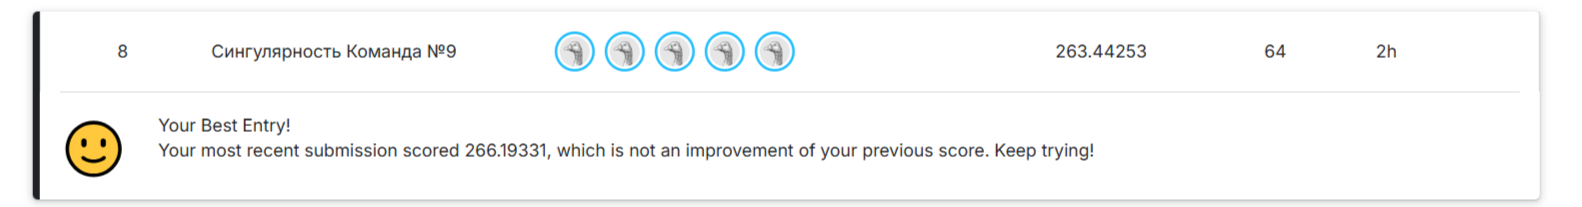

In [1]:
# 1. ИМПОРТ БИБЛИОТЕК
import pandas as pd
import numpy as np
import requests
import io
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
import warnings
from sklearn.metrics import root_mean_squared_error
warnings.filterwarnings('ignore')

In [2]:
# 2. ЗАГРУЗКА ДАННЫХ
def download_from_drive(file_id):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    response = requests.get(url)
    return pd.read_csv(io.StringIO(response.text))

print("Загрузка данных...")
train = download_from_drive("1LLb5yFWq21E08y5EJO5bsxIbWoq-XCPf")
test = download_from_drive("1RrDUHkcouYBtaJ74Ary6NNptQZD49txv")
print("Загрузка завершена")

Загрузка данных...
Загрузка завершена


In [3]:
# 3. Очистка и удаления дубликатов
train = train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})
test = test.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (751, 214), Test shape: (250, 211)


In [4]:
# У некоторых записей таргеты одинаковые, это видно на scatterplot. Оставляем по 1 записи на 1 таргет
orig_train = train
train = train.groupby(["SI", "IC50", "CC50"]).first().reset_index()

In [5]:
# 3. СОЗДАНИЕ ХИМИЧЕСКИХ ПРИЗНАКОВ

def create_features(df):
    df = df.copy()

    # сумма функциональных групп
    fr_cols = [col for col in df.columns if col.startswith('fr_')]
    if len(fr_cols) > 0:
        df['total_fr_groups'] = df[fr_cols].sum(axis=1)

    # масса / TPSA
    df['mass_per_tpsa'] = df['MolWt'] / (df['TPSA'] + 0.1)

    # LogP на единицу массы
    df['logp_per_wt'] = df['MolLogP'] / (df['MolWt'] + 1)

    # диапазон зарядов
    if 'MaxPartialCharge' in df.columns:
        df['charge_range'] = df['MaxPartialCharge'] - df['MinPartialCharge']

    # соотношение гетероатомов
    df['hetero_ratio'] = df['NumHeteroatoms'] / (df['HeavyAtomCount'] + 1)

    # индекс гибкости
    df['flexibility'] = df['NumRotatableBonds'] / (df['RingCount'] + 1)

    # отношение водородных связей к тяжелым атомам
    df['h_to_heavy'] = (df['NumHDonors'] + df['NumHAcceptors']) / (df['HeavyAtomCount'] + 1)

    # плотность колец
    df['ring_density'] = df['RingCount'] / (df['HeavyAtomCount'] + 1)

    # индекс насыщенности
    if 'FractionCSP3' in df.columns:
        df['saturation'] = df['FractionCSP3'] * df['HeavyAtomCount']

    # взаимодействие LogP и TPSA
    df['logp_tpsa'] = df['MolLogP'] * df['TPSA'] / 100

    return df

print("Создание химических признаков...")
train_fe = create_features(train)
test_fe = create_features(test)

feature_cols = [col for col in test_fe.columns if col not in ['IC50', 'CC50', 'SI', 'index']]
print(f"Всего признаков: {len(feature_cols)}")

X_train = train_fe[feature_cols] #.values
X_test = test_fe[feature_cols] #.values

Создание химических признаков...
Всего признаков: 220


In [6]:
# чистка колонок, которые использовать не получится. Константные колонки
cols_w_ununique_vals = []
for col in train.columns:
    unique_val = len(train[col].unique())
    if unique_val == 1:
        cols_w_ununique_vals.append(col)
        print(f"Column {col} has no unique features!")
train.drop(columns=cols_w_ununique_vals, inplace=True)
test.drop(columns=cols_w_ununique_vals, inplace=True)

Column NumRadicalElectrons has no unique features!
Column SMR_VSA8 has no unique features!
Column SlogP_VSA9 has no unique features!
Column fr_N_O has no unique features!
Column fr_SH has no unique features!
Column fr_azide has no unique features!
Column fr_barbitur has no unique features!
Column fr_benzodiazepine has no unique features!
Column fr_diazo has no unique features!
Column fr_dihydropyridine has no unique features!
Column fr_isocyan has no unique features!
Column fr_isothiocyan has no unique features!
Column fr_lactam has no unique features!
Column fr_nitroso has no unique features!
Column fr_phos_acid has no unique features!
Column fr_phos_ester has no unique features!
Column fr_prisulfonamd has no unique features!
Column fr_thiocyan has no unique features!


In [7]:
# чистка колонок, которые использовать не получится. Одинаковые колонки
to_drop_out_list = []
for i in range(len(train.columns) - 1):
    for j in range(i + 1, len(train.columns)):
        if (train[train.columns[i]] != train[train.columns[j]]).sum() == 0:
            print(f"Columns {train.columns[i]} and {train.columns[j]} are the same!")
            to_drop_out_list.append(train.columns[j])
train.drop(columns=to_drop_out_list, inplace=True)
test.drop(columns=to_drop_out_list, inplace=True)

Columns MaxAbsEStateIndex and MaxEStateIndex are the same!
Columns NumAromaticCarbocycles and fr_benzene are the same!
Columns fr_Ar_NH and fr_Nhpyrrole are the same!
Columns fr_COO and fr_COO2 are the same!
Columns fr_nitro_arom and fr_nitro_arom_nonortho are the same!
Columns fr_phenol and fr_phenol_noOrthoHbond are the same!


In [8]:
# 4. ЛОГАРИФМИЧЕСКАЯ ТРАНСФОРМАЦИЯ ДЛЯ SI
# Ключевое улучшение: предсказываем log10(CC50/IC50) вместо прямого SI
# train_fe['SI_log'] = np.log10(train_fe['CC50'] / np.clip(train_fe['IC50'], 1e-6, None))

# Ключевое улучшение 2: возвращаем логарифм SI как было, но делаем результат гарантированно больше 1
train_fe['SI_log'] = np.log10(train_fe['SI'] + 10)

In [9]:
y_train = train_fe[['IC50', 'CC50', "SI", 'SI_log']]

In [10]:
# 5. ПАРАМЕТРЫ МОДЕЛЕЙ
# изменение: сделала менее глубокие деревья для борьбы с переобучением

catboost_params = {
    'iterations': 1500,
    'learning_rate': 0.02,
    'depth': 4,
    'l2_leaf_reg': 4,
    'random_strength': 42,
    'loss_function': 'RMSE',
    'verbose': False,
    'random_seed': 42,
    'early_stopping_rounds': 80
}

xgb_params = {
    'n_estimators': 400,
    'max_depth': 4,
    'learning_rate': 0.02,
    'reg_alpha': 6,
    'reg_lambda': 6,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

lgb_params = {
    'n_estimators': 600,
    'max_depth': 4,
    'learning_rate': 0.02,
    'reg_alpha': 6,
    'reg_lambda': 6,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
    'min_data_in_leaf': 10
}

In [11]:
# 6. КРОСС-ВАЛИДАЦИЯ И ОБУЧЕНИЕ
X_train_raw = X_train
X_test_raw = X_test
kf = KFold(n_splits=5, shuffle=True, random_state=42)


def train_target(y, target_name):
    selector_model = CatBoostRegressor(iterations=400, random_seed=42, verbose=False)
    selector_model.fit(X_train_raw, y_train[target_name])
    
    importance = selector_model.get_feature_importance()
    features_df = pd.DataFrame({'feature': X_train_raw.columns.tolist(), 'importance': importance})
    
    good_features = features_df[features_df['importance'] > 0.01]['feature'].tolist()
    print(f"-> Для [{target_name}] отобрано {len(good_features)} признаков.")
    
    X_train = X_train_raw[good_features]
    X_test = X_test_raw[good_features]
    

    preds_rf = np.zeros(len(test_fe))
    preds_xgb = np.zeros(len(test_fe))
    preds_lgb = np.zeros(len(test_fe))

    preds_train_rf = np.zeros(len(X_train))
    preds_train_xgb = np.zeros(len(X_train))
    preds_train_lgb = np.zeros(len(X_train))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        model_xgb = XGBRegressor(**xgb_params)
        model_xgb.fit(X_tr, y_tr) 
        preds_xgb += model_xgb.predict(X_test) / 5
        preds_train_xgb += model_xgb.predict(X_train) / 5

        model_lgb = LGBMRegressor(**lgb_params)
        model_lgb.fit(X_tr, y_tr) 
        preds_lgb += model_lgb.predict(X_test) / 5
        preds_train_lgb += model_lgb.predict(X_train) / 5

        print(f"Fold {fold+1}/5 - {target_name}")

    return (preds_lgb + preds_xgb) / 2

print("Обучение модели для IC50...")
preds_ic50 = train_target(train_fe['IC50'].values, "IC50")

print("Обучение модели для CC50...")
preds_cc50 = train_target(train_fe['CC50'].values, "CC50")

print("Обучение модели для SI...")
preds_si_log = train_target(train_fe['SI_log'].values, "SI_log")

Обучение модели для IC50...
-> Для [IC50] отобрано 159 признаков.
Fold 1/5 - IC50
Fold 2/5 - IC50
Fold 3/5 - IC50
Fold 4/5 - IC50
Fold 5/5 - IC50
Обучение модели для CC50...
-> Для [CC50] отобрано 166 признаков.
Fold 1/5 - CC50
Fold 2/5 - CC50
Fold 3/5 - CC50
Fold 4/5 - CC50
Fold 5/5 - CC50
Обучение модели для SI...
-> Для [SI_log] отобрано 157 признаков.
Fold 1/5 - SI_log
Fold 2/5 - SI_log
Fold 3/5 - SI_log
Fold 4/5 - SI_log
Fold 5/5 - SI_log


In [12]:
# 7. ПОСТ-ОБРАБОТКА И СОХРАНЕНИЕ
preds_si = 10 ** preds_si_log - 10

submission = pd.DataFrame({
    'index': test.index,
    'IC50': preds_ic50,
    'CC50': preds_cc50,
    'SI': preds_si
})

submission.to_csv('submission_final.csv', index=False)
print("Файл submission_final.csv сохранен")
print(submission.head())

Файл submission_final.csv сохранен
   index        IC50        CC50        SI
0      0  198.111403  391.131151  5.605528
1      1  227.119006  453.554757  3.865921
2      2   55.245517  286.089177  9.399479
3      3  390.456930  612.093479  6.771739
4      4  162.298670  291.224553  3.441938


In [13]:
submission[['IC50', 'CC50', 'SI']].mean()

IC50    240.984034
CC50    639.680458
SI       16.299178
dtype: float64